In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [12]:
file_path = "/content/drive/MyDrive/Front End Web Development/chennai weather combined_dataset.csv"
data = pd.read_csv(file_path)
data.head()

,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,chennai,01-01-2004,27.1,24.1,25.4,28.9,24.1,25.9,21.1,77.8,...,NaN,NaN,NaN,2004-01-01T06:31:03,2004-01-01T17:53:07,0.29,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,43279099999
1,chennai,02-01-2004,28.1,23.1,24.4,29.3,23.1,24.5,19.6,75.5,...,NaN,NaN,NaN,2004-01-02T06:31:27,2004-01-02T17:53:41,0.32,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,43279099999
2,chennai,03-01-2004,28.1,21.1,24.6,28.6,21.1,24.9,18.2,68.3,...,NaN,NaN,NaN,2004-01-03T06:31:49,2004-01-03T17:54:15,0.36,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,43279099999
3,chennai,04-01-2004,28.1,19.1,24.1,28.6,19.1,24.2,17.7,68.9,...,NaN,NaN,NaN,2004-01-04T06:32:10,2004-01-04T17:54:49,0.39,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,43279099999
4,chennai,05-01-2004,28.1,22.1,24.5,29.3,22.1,24.8,19.4,74.3,...,NaN,NaN,NaN,2004-01-05T06:32:31,2004-01-05T17:55:23,0.42,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,43279099999


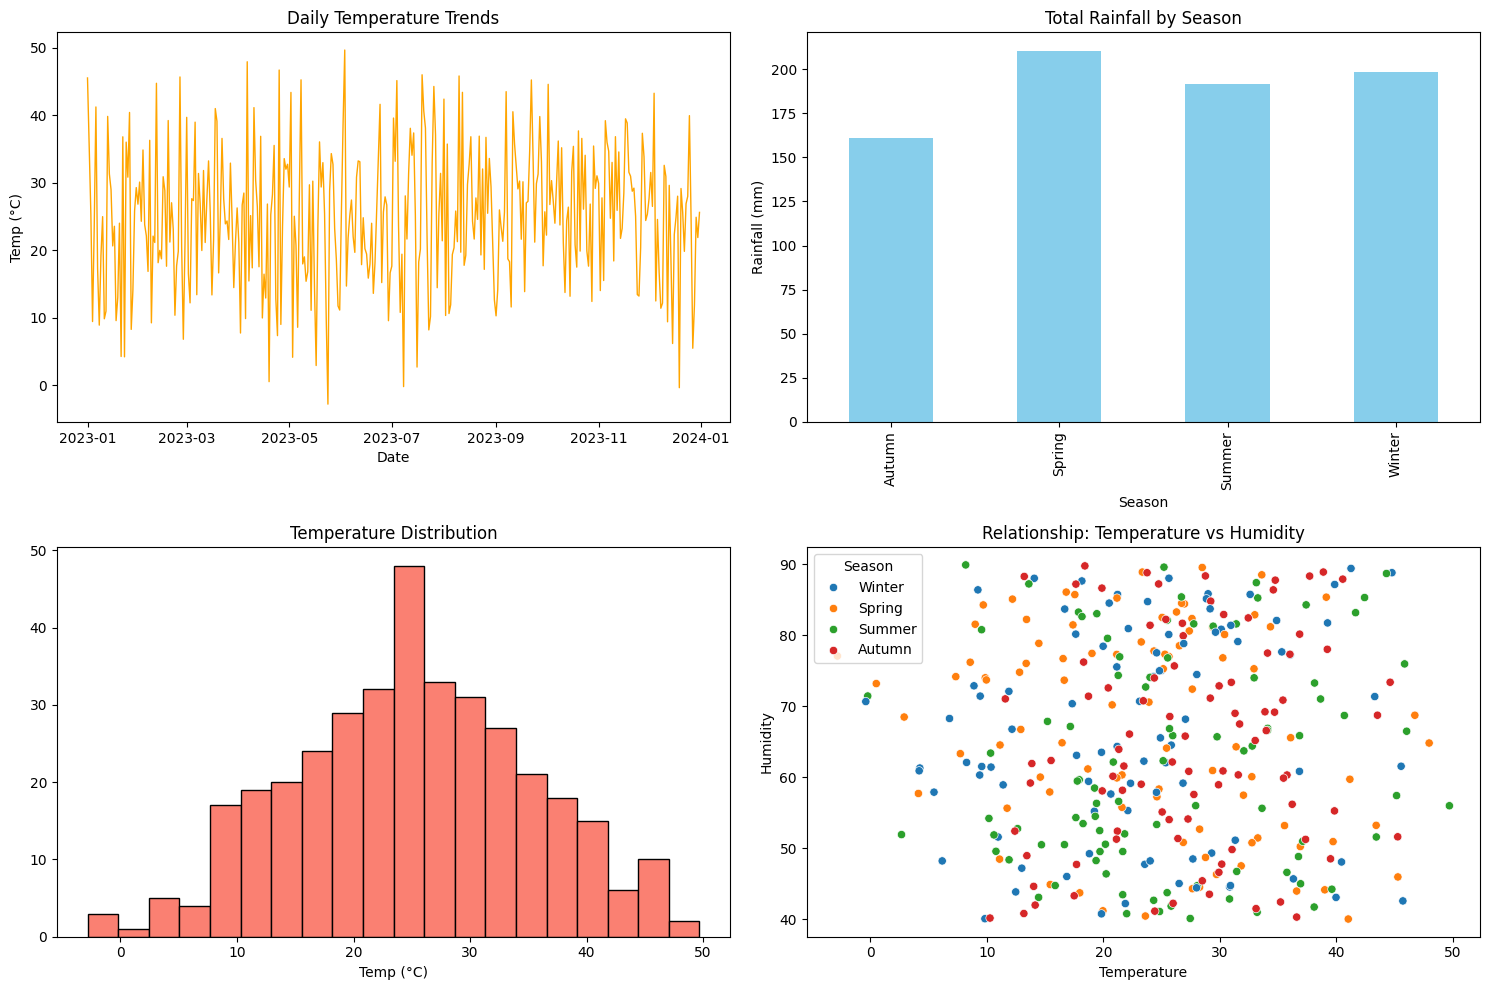

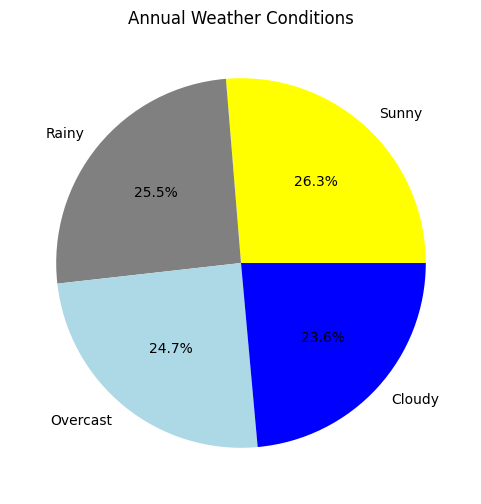

In [13]:
date_range = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')
data = {
    'Date': date_range,
    'Temperature': np.random.normal(loc=25, scale=10, size=len(date_range)),
    'Rainfall': np.random.exponential(scale=2, size=len(date_range)),
    'Humidity': np.random.uniform(40, 90, size=len(date_range)),
    'Condition': np.random.choice(['Sunny', 'Rainy', 'Cloudy', 'Overcast'], len(date_range))
}
df = pd.DataFrame(data)

df['Month'] = df['Date'].dt.month
def get_season(m):
    if m in [12, 1, 2]: return 'Winter'
    elif m in [3, 4, 5]: return 'Spring'
    elif m in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'
df['Season'] = df['Month'].apply(get_season)

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(df['Date'], df['Temperature'], color='orange', linewidth=1)
plt.title('Daily Temperature Trends')
plt.xlabel('Date')
plt.ylabel('Temp (°C)')

plt.subplot(2, 2, 2)
seasonal_rain = df.groupby('Season')['Rainfall'].sum()
seasonal_rain.plot(kind='bar', color='skyblue')
plt.title('Total Rainfall by Season')
plt.ylabel('Rainfall (mm)')

plt.subplot(2, 2, 3)
plt.hist(df['Temperature'], bins=20, color='salmon', edgecolor='black')
plt.title('Temperature Distribution')
plt.xlabel('Temp (°C)')

plt.subplot(2, 2, 4)
sns.scatterplot(x='Temperature', y='Humidity', data=df, hue='Season')
plt.title('Relationship: Temperature vs Humidity')

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
df['Condition'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['yellow', 'grey', 'lightblue', 'blue'])
plt.title('Annual Weather Conditions')
plt.ylabel('')
plt.show()